In [1]:
# IMPORT DATA FROM GOOGLE DRIVE FOLDER (OPTIONAL)

# https://drive.google.com/file/d/1iSqvJEIomtpR6US82bIoFAB-M0-hRWYo/view?usp=sharing # tif delta 1+7 ref + indices
!gdown --id 1iSqvJEIomtpR6US82bIoFAB-M0-hRWYo

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1iSqvJEIomtpR6US82bIoFAB-M0-hRWYo
To: /content/stack_1-7&indices.tif
100% 9.44M/9.44M [00:00<00:00, 28.6MB/s]


In [2]:
# INSTALL LIBRARIES AND DEPENDENCIES
import pandas as pd
import geopandas as gpd
!pip install rasterio
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
# OPEN L8 SCENE IN RASTER FILE AND EXTRACT BANDS DATA

# open tif file
tif_path = '/content/stack_1-7&indices.tif'
tif = rasterio.open(tif_path)

# extract only 1-7 bands data
data_array = tif.read()[0:7] # get 1-7 bands, except ndvi
#print("data shape", data_array.shape)

In [6]:
# RESHAPE/FLATTEN BANDS DATA
data_flatten = data_array.reshape(data_array.shape[0], -1)

Text(0.5, 1.0, 'Reconstructed matrix (validation)')

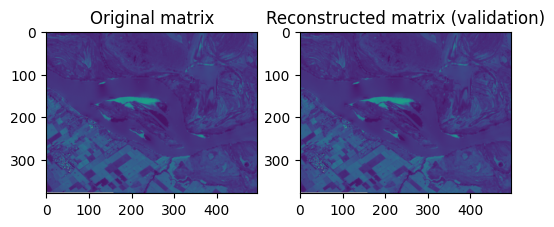

In [7]:
# TEST RESHAPING
## check if reshapping for later PCA implementation, then returns the data structured as needed

# reconstruct 2d matrix
test_array = data_flatten[0]
test_array = test_array.reshape(data_array.shape[1], data_array.shape[2])

# plot and check reconstruction
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].imshow(data_array[0])
ax[0].set_title('Original matrix')
ax[1].imshow(test_array)
ax[1].set_title('Reconstructed matrix (validation)')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


(array([6.0000e+01, 1.0320e+03, 2.1706e+04, 6.3037e+04, 6.5584e+04,
        3.0970e+03, 2.0045e+04, 1.2726e+04, 1.3000e+01, 3.0000e+00]),
 array([-1.94844437, -1.682271  , -1.41609764, -1.14992428, -0.88375092,
        -0.61757755, -0.35140419, -0.08523083,  0.18094254,  0.4471159 ,
         0.7132892 ]),
 <BarContainer object of 10 artists>)

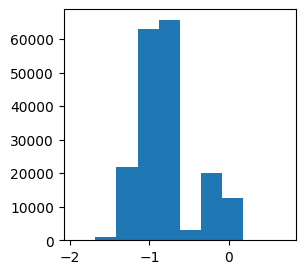

In [8]:
# STANDARDIZE DATA FOR PCA IMPLEMENTATION

# scale data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_flatten)

# plot and visualize scaled data distribution for band n
fig, ax = plt.subplots(figsize=(3, 3))
ax.hist(data_scaled[0])

In [10]:
# TRANSPOSE AND HANDLE NAN VALUES

# transpose data for PCA implementation
data_transp = data_scaled.T

# handle nan values
## create a nan mask array
nan_mask = np.isnan(data_transp)

# impute with column mean (per band)
col_means = np.nanmean(data_transp, axis=0)
data_filled = data_transp.copy()
data_filled[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

In [ ]:
# RUN PCA
pca = PCA() # n_components = none --> keep all components
results_pca = pca.fit_transform(data_filled)

In [ ]:
# EXTRACT VARIANCE DATA FOR EACH PC
array_expVar = pca.explained_variance_ratio_
array_cumExVr = np.cumsum(pca.explained_variance_ratio_)
list_comp = [f'CP{c}' for c in range(1, len(array_expVar)+1)]

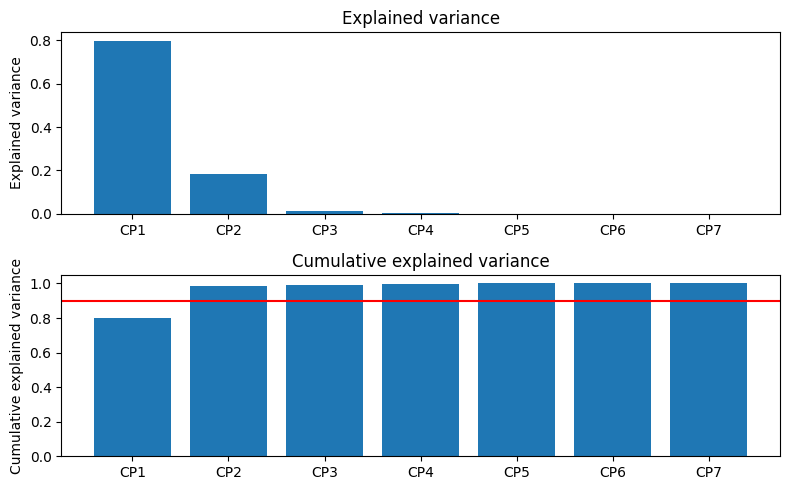

In [ ]:
# PLOT AND VISUALIZE PC VARIANCE RESULTS

fig, ax = plt.subplots(2, 1, figsize=(8, 5))
ax[0].bar(list_comp, array_expVar)
ax[0].set_ylabel('Explained variance')
ax[0].set_title('Explained variance')
ax[1].bar(list_comp, array_cumExVr)
ax[1].axhline(0.9, color='red') # Re-added axhline method
ax[1].set_title('Cumulative explained variance')
ax[1].set_ylabel('Cumulative explained variance')

fig.tight_layout()

In [ ]:
# RECONSTRUCT RESULTS IN DATA FORMAT TO SAVE AS TIF

# select number of pcs for analysis
sel_pc = 3 # choose max pc to include

# create a copy of results
resPCA_copy = results_pca.copy()

# restore nans
resPCA_copy[nan_mask] = np.nan

# transpose and select pcs
resPCA_trp = resPCA_copy.T
resPCA_sel = resPCA_trp[:sel_pc]

# reshape
resPCA_resh = resPCA_sel.reshape(sel_pc, data_array.shape[1], data_array.shape[2])

In [ ]:
# UPDATE THE EXTRACTED ORIGINAL RASTER PROFILE, AND THEN SAVE THE GENERATED TIF WITH PCs BANDS

# Define output file name
outfile = 'stack_selPCs.tif'

# open the original raster and extract profile
with rasterio.open(tif_path) as src:
  profile = src.profile.copy()

# update profile
profile.update(
    tiled=True,
    blockxsize=256,  # Ensure blockxsize is a multiple of 16
    blockysize=256,  # Ensure blockysize is a multiple of 16
    count = sel_pc,   # numbers of bands corresponding to the selected pcs
)

# write the output with the pcs bands
with rasterio.open(outfile, "w", **profile) as dst:
    for i in range(resPCA_resh.shape[0]):
        dst.write(resPCA_resh[i], i + 1)